# Streamlining the Customer Grievance Process

## Context:
As a data scientist working for the front office of a major American multinational bank, you are responsible for enhancing customer service and ensuring compliance with financial regulations. Your current assignment involves analysing the customer complaints the bank has received over the past year.

## Problems:
The current time-consuming manual process for daily triaging and reviewing of customer complaintsThe complaints data is currently underutilized in enhancing the quality of products and services.

## Objective:
The goal is to use NLP techniques, such as text classification and sentiment analysis, to efficiently gain insights into the underlying causes of customer grievances. By leveraging these methods, we aim to better understand and address customer grievances, ultimately improving our grievance redressal process.

## Steps to be done:

1. Prepare text data using appropriate NLP techniques.
2. Efficiently identify the primary factors behind customer grievances using sentiment analysis.
3. Convert insights from sentiment analysis into actionable business strategies for Retail Banking.

## Data understanding:
1. Read data in python environment.
2. Check if the variables have correct datatypes. Make changes wherever necessary.
3. Find the date range
4. Define a function named preprocessing that executes the following series of pre-processing steps in order:
   - Convert text to lowercase
   - Remove numbers
   - Remove stopwords
   - Remove punctuation
   - Apply lemmatization
5. Clean the text under ‘Complaint Description’ using the above function
6. Convert the pre-processed text into a matrix of TF-IDF features for downstream modelling.
7. In order to effectively manage the process, it is critically important to categorise the complaint and pass on to the concerned product department. Consider the department as a target variable and build a classification model.
8. Use SentimentIntensityAnalyzer  to predict sentiments from the complaints. The SentimentIntensityAnalyzer is a class from the vaderSentiment library designed for sentiment analysis. It evaluates text to determine the sentiment scores across four categories: positive, negative, neutral, and compound. The compound score is a normalized value between -1 (most extreme negative) and +1 (most extreme positive), providing an overall sentiment rating. This analyzer is particularly effective for social media and other informal texts, as it can interpret emoticons, acronyms, and slang. It is widely used for tasks like sentiment classification, opinion mining, and customer feedback analysis. Its ease of use and accuracy make it a valuable tool in NLP.
9. How can the score be used by the bank? Share your insights.


## Complaints Dataset
Local File [banking_complaints_2023.csv](.\banking_complaints_2023.csv)

### Data Dictionary
| Field                      | Description                                                         |
|----------------------------|---------------------------------------------------------------------|
| Complaint ID	             | Complaint identifier                                                |
| Date Received	             | MM/DD/YYYY complaint submission date                                |
| Banking Product	         | checking, savings, credit card, prepaid card, debt collection, etc. |
| Department	             | banking department                                                  |
| Issue ID	                 | issue identifier                                                    |
| Complaint Description	     | complaint description text                                          |
| State	                     | state                                                               |
| ZIP	                     | zip code                                                            |
| Bank Response			     | bank response text                                                  |

---

# Part 1: Environment Setup and Library Imports

Before we begin our analysis, we need to import all the necessary libraries. This project requires:

- **Data Manipulation**: `pandas`, `numpy` for data handling
- **NLP Libraries**: `nltk` for text preprocessing, `vaderSentiment` for sentiment analysis
- **Machine Learning**: `scikit-learn` for TF-IDF vectorization and classification models
- **Visualization**: `matplotlib`, `seaborn` for creating insightful visualizations

We'll also download the required NLTK resources for tokenization, stopword removal, and lemmatization.

In [1]:
# =============================================================================
# Library Imports
# =============================================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string
import re

# Sentiment Analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

# Download required NLTK resources
print("Downloading NLTK resources...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("NLTK resources downloaded successfully!")

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

NLTK resources downloaded successfully!


---

# Part 2: Data Understanding

In this section, we will:
1. **Load the dataset** from the CSV file
2. **Examine the data structure** including shape, columns, and data types
3. **Check for missing values** that may need handling
4. **Correct data types** where necessary (especially date fields)
5. **Determine the date range** of complaints received
6. **Explore the distribution** of complaints across different categories

This exploratory data analysis (EDA) helps us understand the data before applying NLP techniques.

## 2.1 Load the Dataset

In [2]:
# Load the banking complaints dataset
df = pd.read_csv('banking_complaints_2023.csv')

# Display basic information about the dataset
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

# Display first few rows
print("\n" + "=" * 60)
print("FIRST 5 RECORDS")
print("=" * 60)
df.head()

DATASET OVERVIEW

Dataset Shape: 7,011 rows × 9 columns

Column Names:
  1. Complaint ID
  2. Date Received
  3. Banking Product
  4. Department
  5. Issue ID
  6. Complaint Description
  7. State
  8. ZIP
  9. Bank Response

FIRST 5 RECORDS


,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response
0,CID76118977,1/1/2023,Checking or savings account,CASA,I_3510635,on XX/XX/XX22 I opened a safe balance account online using my payroll check of over {$600.00} as...,California,92311,Closed with monetary relief
1,CID98703933,1/1/2023,"Credit reporting, credit repair services, or other personal consumer reports",Credit Reports,I_3798538,There is an item from Bank of ABC on my credit report that does not belong to me and must be rem...,California,91344,Closed with explanation
2,CID52036665,1/1/2023,Checking or savings account,CASA,I_3648593,On XX/XX/XX22 I found out that my account was frozen for no apparent reason. I went to the BOA b...,New York,10466,Closed with monetary relief
3,CID62581335,1/1/2023,Credit card or prepaid card,Credit Cards,I_6999080,I've had a credit card for years with Bank of ABC. In XX/XX/XXXX I paid off my balance and becau...,California,92127,Closed with monetary relief
4,CID65731164,1/1/2023,Checking or savings account,CASA,I_3648593,This issue has to do with the way that Bank of ABC does their account linking in their Bill Pay ...,New Jersey,7946,Closed with explanation


## 2.2 Check Data Types and Missing Values

It's important to verify that each column has the appropriate data type. In particular:
- **Date Received** should be converted to datetime format for temporal analysis
- **Complaint Description** should be string type for text processing
- Numeric identifiers should be treated as categorical/string types

In [4]:
# Check current data types
print("=" * 60)
print("CURRENT DATA TYPES")
print("=" * 60)
print(df.dtypes)

# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_data)

# Summary statistics for numerical columns
print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

CURRENT DATA TYPES
Complaint ID             object
Date Received            object
Banking Product          object
Department               object
Issue ID                 object
Complaint Description    object
State                    object
ZIP                      object
Bank Response            object
dtype: object

MISSING VALUES ANALYSIS
                       Missing Count  Missing %
Complaint ID                       0       0.00
Date Received                      0       0.00
Banking Product                    0       0.00
Department                         0       0.00
Issue ID                           0       0.00
Complaint Description              0       0.00
State                             27       0.39
ZIP                               30       0.43
Bank Response                      0       0.00

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7011 entries, 0 to 7010
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---

## 2.3 Data Type Corrections and Date Range

Now we'll convert the `Date Received` column to proper datetime format and determine the date range of our complaints data.

In [6]:
# Convert 'Date Received' to datetime format
df['Date Received'] = pd.to_datetime(df['Date Received'], format='%m/%d/%Y')

# Verify the conversion
print("=" * 60)
print("DATA TYPE AFTER CONVERSION")
print("=" * 60)
print(f"Date Received dtype: {df['Date Received'].dtype}")

# Find the date range
date_min = df['Date Received'].min()
date_max = df['Date Received'].max()
date_range_days = (date_max - date_min).days

print("\n" + "=" * 60)
print("DATE RANGE ANALYSIS")
print("=" * 60)
print(f"Earliest Complaint: {date_min.strftime('%B %d, %Y')}")
print(f"Latest Complaint:   {date_max.strftime('%B %d, %Y')}")
print(f"Total Days Covered: {date_range_days} days ({date_range_days/30:.1f} months)")
print(f"Total Complaints:   {len(df):,}")

DATA TYPE AFTER CONVERSION
Date Received dtype: datetime64[ns]

DATE RANGE ANALYSIS
Earliest Complaint: January 01, 2023
Latest Complaint:   October 21, 2023
Total Days Covered: 293 days (9.8 months)
Total Complaints:   7,011


## 2.4 Exploratory Data Analysis (EDA)

Let's explore the distribution of complaints across different categories to understand the data better:
- **Department distribution** - Which departments receive the most complaints?
- **Banking Product distribution** - Which products generate the most complaints?
- **State distribution** - Geographic distribution of complaints
- **Bank Response distribution** - How are complaints being resolved?

In [7]:
# Analyze categorical distributions
print("=" * 60)
print("DEPARTMENT DISTRIBUTION (Target Variable)")
print("=" * 60)
dept_counts = df['Department'].value_counts()
print(dept_counts)
print(f"\nNumber of unique departments: {df['Department'].nunique()}")

print("\n" + "=" * 60)
print("BANKING PRODUCT DISTRIBUTION")
print("=" * 60)
product_counts = df['Banking Product'].value_counts()
print(product_counts)

print("\n" + "=" * 60)
print("BANK RESPONSE DISTRIBUTION")
print("=" * 60)
response_counts = df['Bank Response'].value_counts()
print(response_counts)

print("\n" + "=" * 60)
print("TOP 10 STATES BY COMPLAINT COUNT")
print("=" * 60)
state_counts = df['State'].value_counts().head(10)
print(state_counts)

DEPARTMENT DISTRIBUTION (Target Variable)
Department
CASA              1655
Credit Cards      1609
Loans             1111
Credit Reports    1109
Mortgage           848
Remittance         422
Others             257
Name: count, dtype: int64

Number of unique departments: 7

BANKING PRODUCT DISTRIBUTION
Banking Product
Checking or savings account                                                     1655
Credit card or prepaid card                                                     1233
Mortgage                                                                         848
Debt collection                                                                  748
Credit reporting, credit repair services, or other personal consumer reports     559
Credit reporting                                                                 550
Money transfer, virtual currency, or money service                               411
Credit card                                                                      359
B

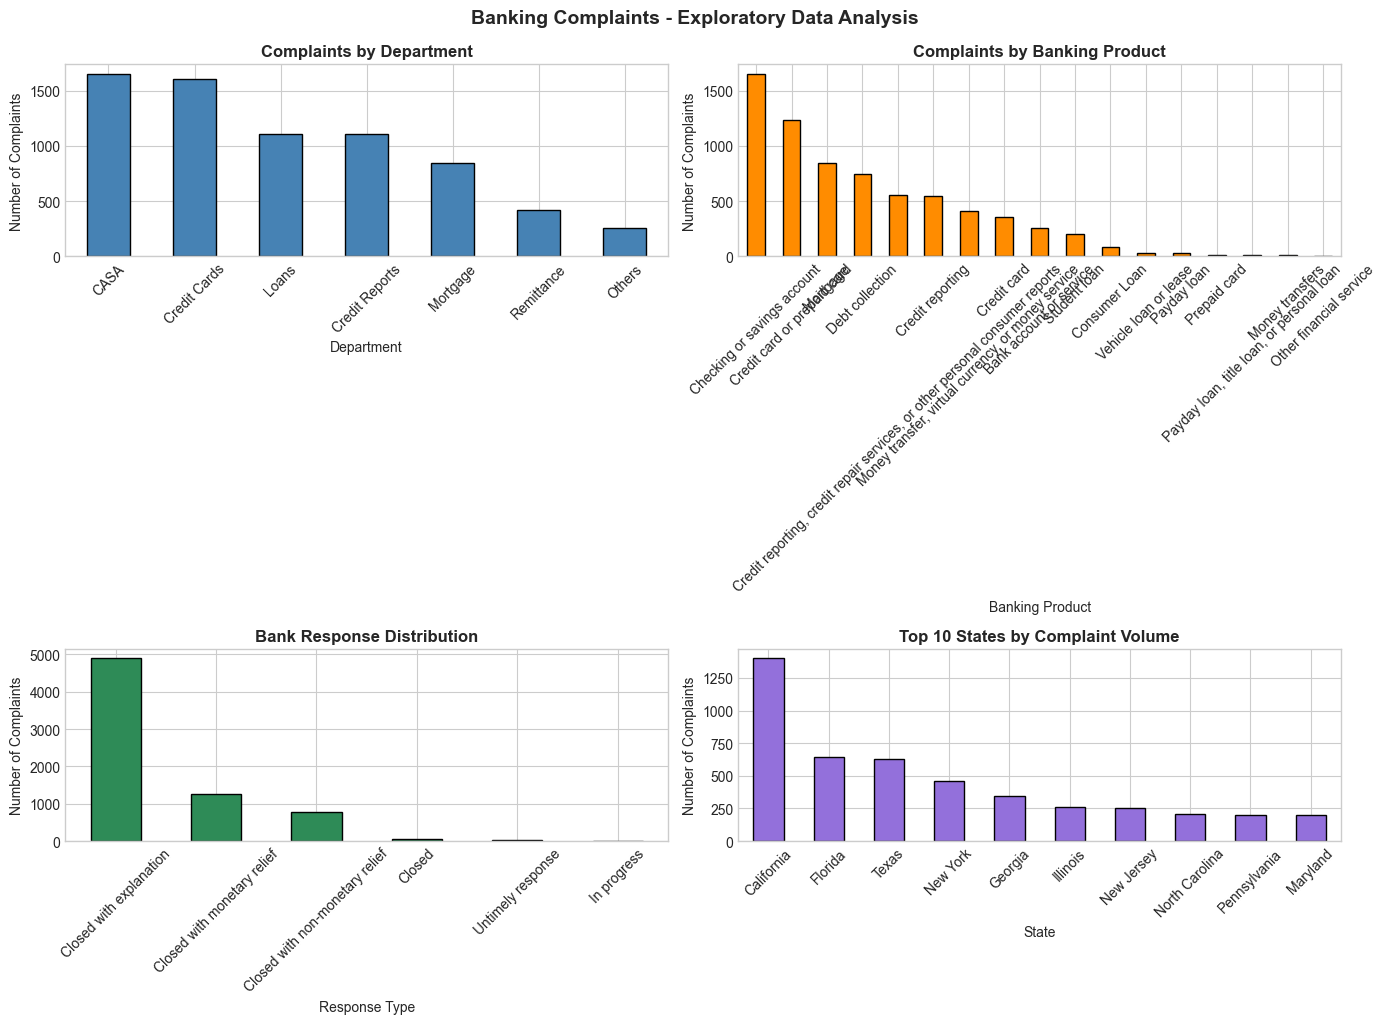

In [8]:
# Create visualizations for categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Department Distribution
ax1 = axes[0, 0]
dept_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Complaints by Department', fontsize=12, fontweight='bold')
ax1.set_xlabel('Department')
ax1.set_ylabel('Number of Complaints')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Banking Product Distribution
ax2 = axes[0, 1]
product_counts.plot(kind='bar', ax=ax2, color='darkorange', edgecolor='black')
ax2.set_title('Complaints by Banking Product', fontsize=12, fontweight='bold')
ax2.set_xlabel('Banking Product')
ax2.set_ylabel('Number of Complaints')
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Bank Response Distribution
ax3 = axes[1, 0]
response_counts.plot(kind='bar', ax=ax3, color='seagreen', edgecolor='black')
ax3.set_title('Bank Response Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Response Type')
ax3.set_ylabel('Number of Complaints')
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Top 10 States
ax4 = axes[1, 1]
state_counts.plot(kind='bar', ax=ax4, color='mediumpurple', edgecolor='black')
ax4.set_title('Top 10 States by Complaint Volume', fontsize=12, fontweight='bold')
ax4.set_xlabel('State')
ax4.set_ylabel('Number of Complaints')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Banking Complaints - Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.show()

---

# Part 3: Text Preprocessing

Text preprocessing is a critical step in any NLP pipeline. Raw text data contains noise that can negatively impact model performance. Our preprocessing pipeline will:

1. **Convert to lowercase** - Ensures consistency (e.g., "Bank" and "bank" are treated the same)
2. **Remove numbers** - Numbers often don't contribute to sentiment or classification
3. **Remove stopwords** - Common words like "the", "is", "at" that don't carry meaningful information
4. **Remove punctuation** - Punctuation marks that may interfere with tokenization
5. **Apply lemmatization** - Reduces words to their base form (e.g., "running" → "run")

This preprocessing approach follows NLP best practices and ensures clean, consistent text for downstream modeling.

## 3.1 Define the Preprocessing Function

The `preprocessing` function implements all the text cleaning steps in the specified order. We use NLTK's WordNetLemmatizer for lemmatization, which is effective for reducing words to their dictionary form.

In [9]:
# Initialize the lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocessing(text):
    """
    Preprocesses text data through a series of NLP cleaning steps.
    
    Parameters:
    -----------
    text : str
        Raw text string to be preprocessed
        
    Returns:
    --------
    str
        Cleaned and preprocessed text
        
    Processing Steps:
    1. Convert to lowercase
    2. Remove numbers
    3. Remove stopwords
    4. Remove punctuation
    5. Apply lemmatization
    """
    # Handle missing values
    if pd.isna(text) or text is None:
        return ""
    
    # Convert to string if not already
    text = str(text)
    
    # Step 1: Convert text to lowercase
    text = text.lower()
    
    # Step 2: Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Step 3: Tokenize the text
    tokens = word_tokenize(text)
    
    # Step 4: Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]
    
    # Step 5: Remove punctuation
    tokens = [token for token in tokens if token not in string.punctuation]
    
    # Step 6: Apply lemmatization
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Join tokens back into a single string
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text

# Test the preprocessing function with a sample
sample_text = df['Complaint Description'].iloc[0]
print("=" * 60)
print("PREPROCESSING FUNCTION TEST")
print("=" * 60)
print("\nORIGINAL TEXT (first 500 characters):")
print("-" * 40)
print(sample_text[:500] + "...")
print("\nPREPROCESSED TEXT (first 500 characters):")
print("-" * 40)
preprocessed_sample = preprocessing(sample_text)
print(preprocessed_sample[:500] + "...")

PREPROCESSING FUNCTION TEST

ORIGINAL TEXT (first 500 characters):
----------------------------------------
on XX/XX/XX22 I opened a safe balance account online using my payroll check of over {$600.00} as my account opener. On XX/XX/XX22, I attempted to login to my app and received a " account locked contact customer service @ XXXX '' error message. I placed the call and was told I would have to go to a branch to verify my identity, which I did. At the same time, I was told I had a positive balance of of {$650.00} and could make a withdrawal from the teller, which I did for {$400.00} leaving a balance...

PREPROCESSED TEXT (first 500 characters):
----------------------------------------
xx/xx/xx opened safe balance account online using payroll check account opener xx/xx/xx attempted login app received `` account locked contact customer service xxxx `` error message placed call told would go branch verify identity time told positive balance could make withdrawal teller leaving balance s

## 3.2 Apply Preprocessing to All Complaints

Now we'll apply the preprocessing function to clean all complaint descriptions in our dataset. This creates a new column `cleaned_complaint` that will be used for TF-IDF vectorization and classification.

In [11]:
# Apply preprocessing to the 'Complaint Description' column
print("Preprocessing complaint descriptions...")
print("This may take a few moments...")

df['cleaned_complaint'] = df['Complaint Description'].apply(preprocessing)

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print(f"Total complaints processed: {len(df):,}")

# Show before/after comparison
print("\n" + "=" * 60)
print("BEFORE vs AFTER PREPROCESSING - Sample Comparisons")
print("=" * 60)

for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"Original (truncated):    {df['Complaint Description'].iloc[i][:150]}...")
    print(f"Preprocessed (truncated): {df['cleaned_complaint'].iloc[i][:150]}...")

# Check for any empty preprocessed texts
empty_count = (df['cleaned_complaint'] == '').sum()
print(f"\n\nNumber of empty preprocessed texts: {empty_count}")

Preprocessing complaint descriptions...
This may take a few moments...

PREPROCESSING COMPLETE
Total complaints processed: 7,011

BEFORE vs AFTER PREPROCESSING - Sample Comparisons

--- Example 1 ---
Original (truncated):    on XX/XX/XX22 I opened a safe balance account online using my payroll check of over {$600.00} as my account opener. On XX/XX/XX22, I attempted to logi...
Preprocessed (truncated): xx/xx/xx opened safe balance account online using payroll check account opener xx/xx/xx attempted login app received `` account locked contact custome...

--- Example 2 ---
Original (truncated):    There is an item from Bank of ABC on my credit report that does not belong to me and must be removed because its a fraud item but they always return b...
Preprocessed (truncated): item bank abc credit report belong must removed fraud item always return back confirming account belongs proof need item removed credit report effecti...

--- Example 3 ---
Original (truncated):    On XX/XX/XX22 I fou

---

# Part 4: Text Feature Engineering (TF-IDF)

## What is TF-IDF?

**TF-IDF (Term Frequency-Inverse Document Frequency)** is a numerical statistic that reflects how important a word is to a document in a collection. It's widely used in text mining and NLP for feature extraction.

- **Term Frequency (TF)**: How often a word appears in a document
- **Inverse Document Frequency (IDF)**: Measures how rare or common a word is across all documents

**TF-IDF = TF × IDF**

Words that appear frequently in a document but rarely across the corpus get higher TF-IDF scores, making them more distinctive features.

### Our TF-IDF Configuration:
- **max_features=5000**: Limit vocabulary to top 5000 terms by frequency
- **min_df=5**: Ignore terms appearing in fewer than 5 documents
- **max_df=0.95**: Ignore terms appearing in more than 95% of documents
- **ngram_range=(1,2)**: Include both unigrams and bigrams for better context

## 4.1 Create TF-IDF Matrix

In [12]:
# Initialize the TF-IDF Vectorizer with optimized parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # Limit to top 5000 features
    min_df=5,               # Minimum document frequency
    max_df=0.95,            # Maximum document frequency
    ngram_range=(1, 2),     # Include unigrams and bigrams
    sublinear_tf=True       # Apply sublinear TF scaling (1 + log(tf))
)

# Fit and transform the cleaned complaint text
print("Creating TF-IDF matrix...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_complaint'])

print("\n" + "=" * 60)
print("TF-IDF MATRIX CREATED SUCCESSFULLY")
print("=" * 60)
print(f"Matrix Shape: {tfidf_matrix.shape}")
print(f"  - Number of documents (complaints): {tfidf_matrix.shape[0]:,}")
print(f"  - Number of features (terms): {tfidf_matrix.shape[1]:,}")
print(f"Matrix Type: {type(tfidf_matrix).__name__}")
print(f"Memory Usage: {tfidf_matrix.data.nbytes / 1024 / 1024:.2f} MB")

Creating TF-IDF matrix...

TF-IDF MATRIX CREATED SUCCESSFULLY
Matrix Shape: (7011, 5000)
  - Number of documents (complaints): 7,011
  - Number of features (terms): 5,000
Matrix Type: csr_matrix
Memory Usage: 4.29 MB


## 4.2 Explore Top TF-IDF Features

Let's examine the most important terms identified by our TF-IDF vectorizer. These terms are the most distinctive across our complaint corpus.

TOP 20 TF-IDF TERMS (Most Important Features)
       term  mean_tfidf
       xxxx    0.064399
         xx    0.047042
  xxxx xxxx    0.045029
    account    0.041170
       bank    0.040677
      xx xx    0.035054
     credit    0.034209
        abc    0.032988
   bank abc    0.032692
       card    0.026766
    xx xxxx    0.024854
    payment    0.022192
     report    0.022095
       time    0.020486
      would    0.020212
   received    0.019780
       told    0.019501
      money    0.019470
information    0.018974
     called    0.018221


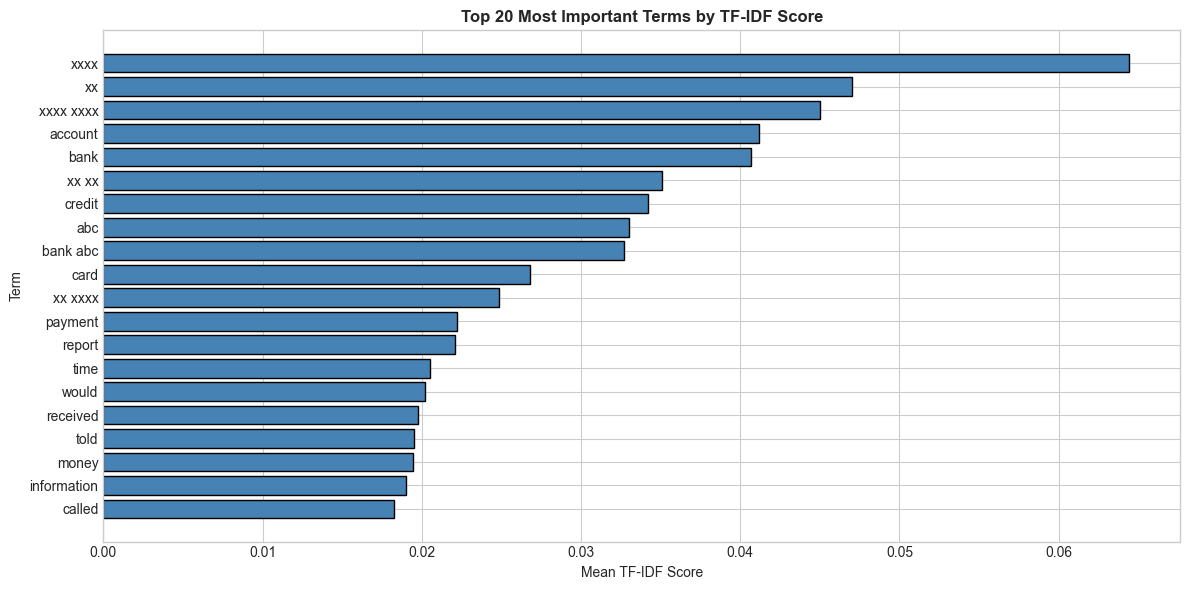

In [14]:
# Get feature names from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculate mean TF-IDF score for each term across all documents
mean_tfidf_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()

# Create a DataFrame of terms and their scores
tfidf_df = pd.DataFrame({
    'term': feature_names,
    'mean_tfidf': mean_tfidf_scores
}).sort_values('mean_tfidf', ascending=False)

# Display top 20 terms
print("=" * 60)
print("TOP 20 TF-IDF TERMS (Most Important Features)")
print("=" * 60)
print(tfidf_df.head(20).to_string(index=False))

# Visualize top 20 terms
plt.figure(figsize=(12, 6))
top_20 = tfidf_df.head(20)
plt.barh(range(len(top_20)), top_20['mean_tfidf'].values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top_20)), top_20['term'].values)
plt.xlabel('Mean TF-IDF Score')
plt.ylabel('Term')
plt.title('Top 20 Most Important Terms by TF-IDF Score', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---

# Part 5: Complaint Classification Model

## Objective

To effectively manage the grievance process, it's critically important to **automatically categorize complaints** and route them to the correct department. This automated triage system can:

- **Reduce manual effort** in complaint routing
- **Speed up resolution times** by directing complaints to the right team immediately
- **Improve customer satisfaction** through faster response times

## Target Variable: Department

We'll build a **multi-class classification model** that predicts which department should handle a complaint based on the complaint text.

## Model Approach

We'll compare multiple classification algorithms:
1. **Logistic Regression** - Simple, interpretable baseline
2. **Multinomial Naive Bayes** - Fast and effective for text classification
3. **Random Forest** - Ensemble method that can capture complex patterns

We'll evaluate models using:
- **Accuracy**: Overall correct predictions
- **Precision/Recall/F1-Score**: Per-class performance
- **Confusion Matrix**: Visual representation of prediction errors

## 5.1 Prepare Data for Classification

First, we'll encode the target variable (Department) and split the data into training and testing sets.

In [15]:
# Encode the target variable (Department)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Department'])

# Store class names for later use
class_names = label_encoder.classes_

print("=" * 60)
print("TARGET VARIABLE ENCODING")
print("=" * 60)
print("\nDepartment to Encoded Value Mapping:")
for i, dept in enumerate(class_names):
    count = (y == i).sum()
    print(f"  {i}: {dept} ({count:,} samples)")

# Features (TF-IDF matrix)
X = tfidf_matrix

# Split data into training (80%) and testing (20%) sets
# Using stratify to maintain class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)
print(f"Training set size: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Testing set size:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(y)*100:.1f}%)")
print(f"Feature dimensions: {X_train.shape[1]:,} features")

TARGET VARIABLE ENCODING

Department to Encoded Value Mapping:
  0: CASA (1,655 samples)
  1: Credit Cards (1,609 samples)
  2: Credit Reports (1,109 samples)
  3: Loans (1,111 samples)
  4: Mortgage (848 samples)
  5: Others (257 samples)
  6: Remittance (422 samples)

TRAIN-TEST SPLIT
Training set size: 5,608 samples (80.0%)
Testing set size:  1,403 samples (20.0%)
Feature dimensions: 5,000 features


## 5.2 Train and Compare Multiple Classification Models

We'll train three different models and compare their performance to select the best one for our complaint routing system.

In [16]:
# Define the models to compare
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced',
        random_state=42
    ),
    'Multinomial Naive Bayes': MultinomialNB(
        alpha=0.1  # Smoothing parameter
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

# Train and evaluate each model
results = {}

print("=" * 60)
print("MODEL TRAINING AND EVALUATION")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': accuracy
    }
    
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Summary comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()]
}).sort_values('Accuracy', ascending=False)
print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest Performing Model: {best_model_name}")

MODEL TRAINING AND EVALUATION

Training Logistic Regression...
  Accuracy: 0.7548 (75.48%)

Training Multinomial Naive Bayes...
  Accuracy: 0.7270 (72.70%)

Training Random Forest...
  Accuracy: 0.6949 (69.49%)

MODEL COMPARISON SUMMARY
                  Model  Accuracy
    Logistic Regression  0.754811
Multinomial Naive Bayes  0.727014
          Random Forest  0.694939

Best Performing Model: Logistic Regression


## 5.3 Detailed Evaluation of Best Model

Let's examine the performance of our best model in detail with a classification report and confusion matrix.

DETAILED EVALUATION: Logistic Regression

Classification Report:
------------------------------------------------------------
                precision    recall  f1-score   support

          CASA       0.76      0.75      0.75       331
  Credit Cards       0.77      0.71      0.74       322
Credit Reports       0.75      0.73      0.74       222
         Loans       0.76      0.77      0.76       222
      Mortgage       0.89      0.91      0.90       170
        Others       0.63      0.57      0.60        51
    Remittance       0.56      0.76      0.64        85

      accuracy                           0.75      1403
     macro avg       0.73      0.74      0.73      1403
  weighted avg       0.76      0.75      0.76      1403



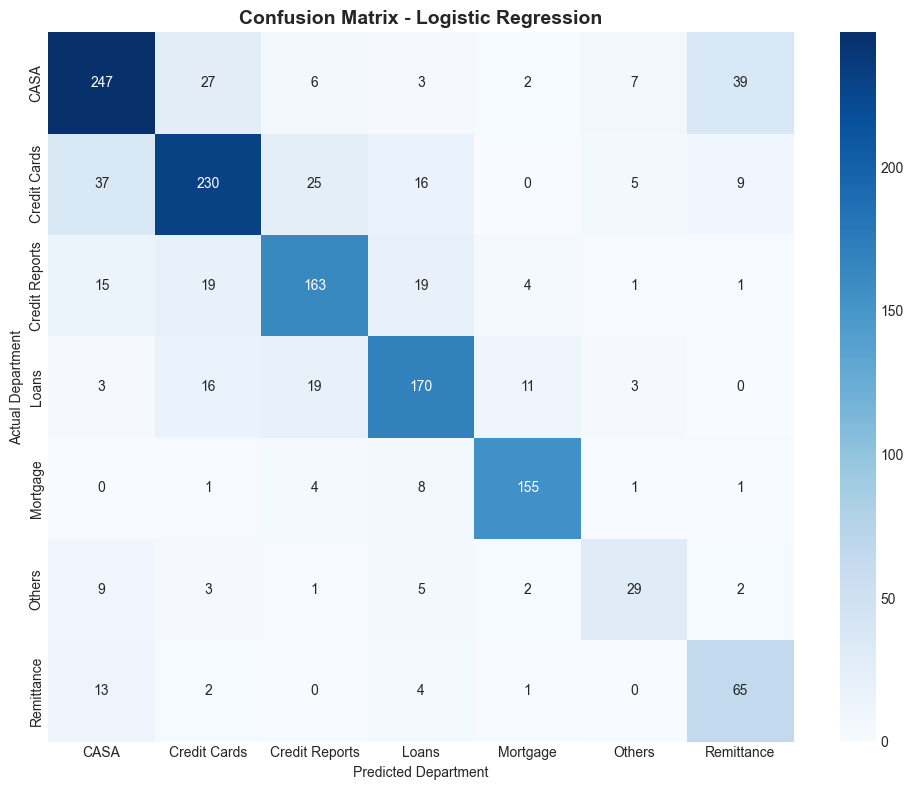


PER-CLASS PERFORMANCE ANALYSIS
CASA: 247/331 correct (74.6%)
Credit Cards: 230/322 correct (71.4%)
Credit Reports: 163/222 correct (73.4%)
Loans: 170/222 correct (76.6%)
Mortgage: 155/170 correct (91.2%)
Others: 29/51 correct (56.9%)
Remittance: 65/85 correct (76.5%)


In [18]:
# Get predictions from the best model
best_predictions = results[best_model_name]['predictions']

# Print detailed classification report
print("=" * 60)
print(f"DETAILED EVALUATION: {best_model_name}")
print("=" * 60)
print("\nClassification Report:")
print("-" * 60)
print(classification_report(y_test, best_predictions, target_names=class_names))

# Create confusion matrix
cm = confusion_matrix(y_test, best_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Department')
plt.ylabel('Actual Department')
plt.tight_layout()
plt.show()

# Calculate per-class metrics
print("\n" + "=" * 60)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("=" * 60)
for i, dept in enumerate(class_names):
    correct = cm[i, i]
    total = cm[i, :].sum()
    accuracy = correct / total if total > 0 else 0
    print(f"{dept}: {correct}/{total} correct ({accuracy*100:.1f}%)")

---

# Part 6: Sentiment Analysis with VADER

## About VADER (Valence Aware Dictionary and sEntiment Reasoner)

**VADER** is a lexicon and rule-based sentiment analysis tool specifically designed for social media and informal text. It's particularly effective for:

- **Customer feedback analysis** - Perfect for complaint text
- **Emoticon and slang interpretation** - Handles informal language
- **Intensity modification** - Recognizes words like "very", "extremely"
- **Punctuation sensitivity** - "Good!!!" is more positive than "Good"

### VADER Output Scores:
- **neg**: Proportion of negative sentiment (0 to 1)
- **neu**: Proportion of neutral sentiment (0 to 1)
- **pos**: Proportion of positive sentiment (0 to 1)
- **compound**: Normalized aggregate score (-1 to +1)
  - compound >= 0.05: Positive sentiment
  - compound <= -0.05: Negative sentiment
  - -0.05 < compound < 0.05: Neutral sentiment

VADER is ideal for analyzing customer complaints as it can capture the emotional tone of grievances without requiring training data.

## 6.1 Apply VADER Sentiment Analysis

We'll use the `SentimentIntensityAnalyzer` from vaderSentiment to analyze the sentiment of each complaint. Note that VADER works best on original (non-preprocessed) text as it leverages punctuation, capitalization, and other textual cues.

In [19]:
# Initialize the VADER SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment_scores(text):
    """
    Analyzes text and returns VADER sentiment scores.
    
    Parameters:
    -----------
    text : str
        Text to analyze
        
    Returns:
    --------
    dict
        Dictionary containing neg, neu, pos, and compound scores
    """
    if pd.isna(text) or text is None:
        return {'neg': 0, 'neu': 1, 'pos': 0, 'compound': 0}
    return analyzer.polarity_scores(str(text))

# Apply sentiment analysis to original complaint text (not preprocessed)
# VADER works better with original text including punctuation and capitalization
print("Performing sentiment analysis on complaints...")
print("This may take a moment...")

# Get sentiment scores for each complaint
sentiment_scores = df['Complaint Description'].apply(get_sentiment_scores)

# Extract individual sentiment components
df['sentiment_neg'] = sentiment_scores.apply(lambda x: x['neg'])
df['sentiment_neu'] = sentiment_scores.apply(lambda x: x['neu'])
df['sentiment_pos'] = sentiment_scores.apply(lambda x: x['pos'])
df['sentiment_compound'] = sentiment_scores.apply(lambda x: x['compound'])

# Classify sentiment based on compound score
def classify_sentiment(compound):
    """Classify sentiment based on compound score threshold."""
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_compound'].apply(classify_sentiment)

print("\n" + "=" * 60)
print("SENTIMENT ANALYSIS COMPLETE")
print("=" * 60)
print(f"Total complaints analyzed: {len(df):,}")

# Display sample results
print("\n" + "=" * 60)
print("SAMPLE SENTIMENT ANALYSIS RESULTS")
print("=" * 60)
sample_cols = ['Complaint ID', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 
               'sentiment_compound', 'sentiment_label']
print(df[sample_cols].head(10).to_string(index=False))

Performing sentiment analysis on complaints...
This may take a moment...

SENTIMENT ANALYSIS COMPLETE
Total complaints analyzed: 7,011

SAMPLE SENTIMENT ANALYSIS RESULTS
Complaint ID  sentiment_neg  sentiment_neu  sentiment_pos  sentiment_compound sentiment_label
 CID76118977          0.081          0.893          0.026             -0.9488        Negative
 CID98703933          0.095          0.817          0.089             -0.1207        Negative
 CID52036665          0.050          0.950          0.000             -0.5267        Negative
 CID62581335          0.089          0.848          0.064             -0.8796        Negative
 CID65731164          0.053          0.850          0.097              0.9357        Positive
 CID85022786          0.037          0.891          0.073              0.1901        Positive
 CID90664453          0.048          0.952          0.000             -0.1027        Negative
 CID95238935          0.131          0.850          0.018             -0.9423 

## 6.2 Sentiment Distribution Analysis

Let's explore the overall sentiment distribution of complaints and analyze how sentiment varies across different dimensions like department, product, and time.

OVERALL SENTIMENT DISTRIBUTION
sentiment_label
Negative    3820
Positive    2874
Neutral      317
Name: count, dtype: int64

Percentages:
  Negative: 54.5%
  Positive: 41.0%
  Neutral: 4.5%

COMPOUND SCORE STATISTICS
count    7011.000000
mean       -0.118620
std         0.695825
min        -0.999600
25%        -0.811450
50%        -0.226300
75%         0.571900
max         0.999400
Name: sentiment_compound, dtype: float64


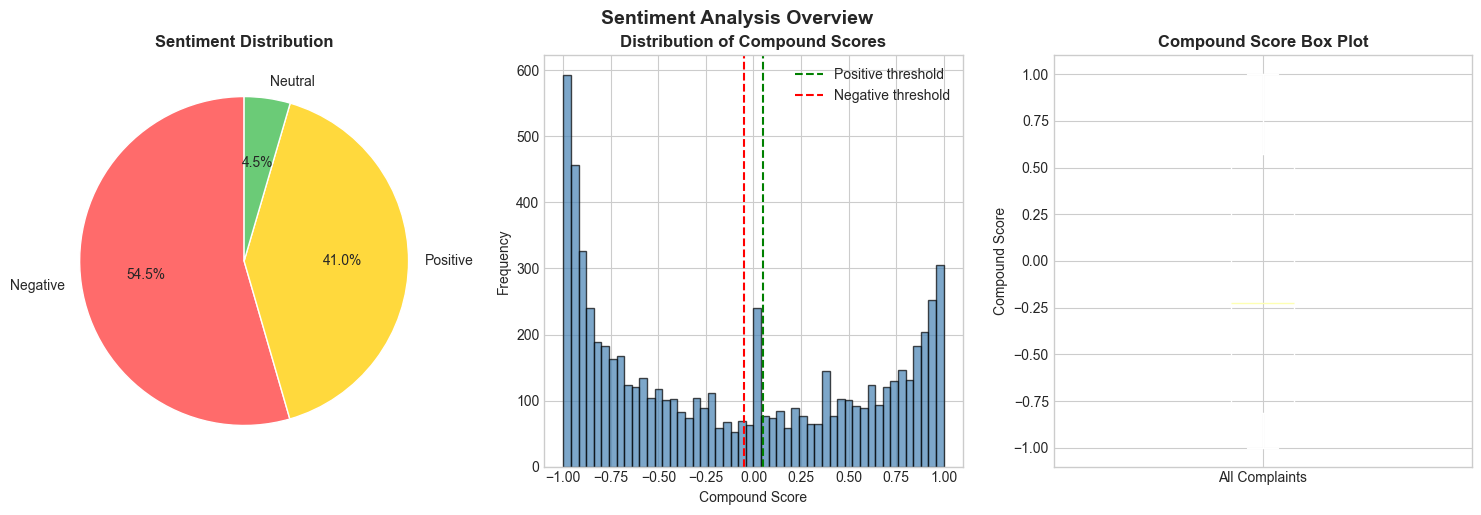

In [20]:
# Overall sentiment distribution
print("=" * 60)
print("OVERALL SENTIMENT DISTRIBUTION")
print("=" * 60)
sentiment_dist = df['sentiment_label'].value_counts()
print(sentiment_dist)
print(f"\nPercentages:")
for label, count in sentiment_dist.items():
    print(f"  {label}: {count/len(df)*100:.1f}%")

# Statistical summary of compound scores
print("\n" + "=" * 60)
print("COMPOUND SCORE STATISTICS")
print("=" * 60)
print(df['sentiment_compound'].describe())

# Visualize sentiment distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Sentiment Label Distribution (Pie Chart)
ax1 = axes[0]
colors = ['#ff6b6b', '#ffd93d', '#6bcb77']
sentiment_dist.plot(kind='pie', ax=ax1, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Sentiment Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('')

# Plot 2: Compound Score Distribution (Histogram)
ax2 = axes[1]
ax2.hist(df['sentiment_compound'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
ax2.axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
ax2.set_xlabel('Compound Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Compound Scores', fontsize=12, fontweight='bold')
ax2.legend()

# Plot 3: Box plot of compound scores
ax3 = axes[2]
ax3.boxplot(df['sentiment_compound'])
ax3.set_ylabel('Compound Score')
ax3.set_title('Compound Score Box Plot', fontsize=12, fontweight='bold')
ax3.set_xticklabels(['All Complaints'])

plt.tight_layout()
plt.suptitle('Sentiment Analysis Overview', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 6.3 Sentiment Analysis by Department and Product

Understanding which departments and products generate the most negative sentiment helps prioritize improvement efforts.

SENTIMENT ANALYSIS BY DEPARTMENT
                Compound Mean  Compound Std  Count  Neg Mean  Pos Mean
Department                                                            
Remittance             -0.321         0.651    422     0.071     0.049
CASA                   -0.309         0.636   1655     0.073     0.048
Others                 -0.145         0.689    257     0.070     0.059
Loans                  -0.132         0.670   1111     0.086     0.067
Mortgage               -0.045         0.712    848     0.064     0.060
Credit Cards           -0.024         0.744   1609     0.075     0.080
Credit Reports          0.068         0.653   1109     0.078     0.088

SENTIMENT ANALYSIS BY BANKING PRODUCT
                                                                              Compound Mean  \
Banking Product                                                                               
Money transfers                                                                      -0.470   
Prep

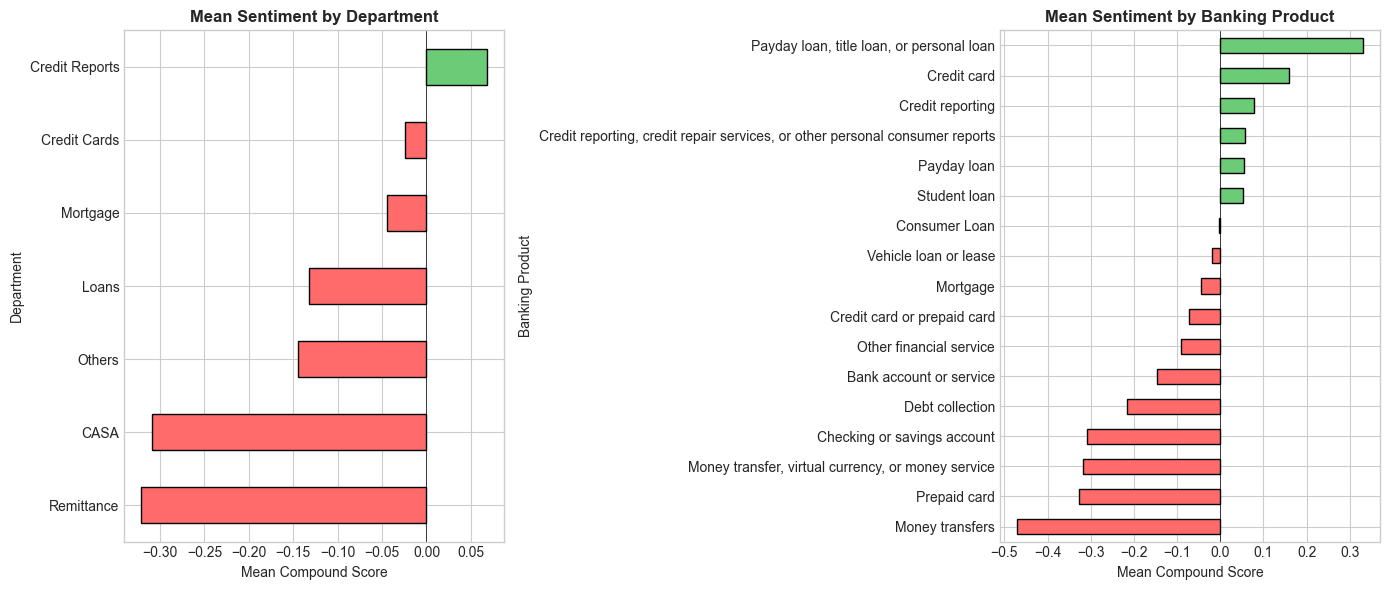

In [21]:
# Sentiment by Department
print("=" * 60)
print("SENTIMENT ANALYSIS BY DEPARTMENT")
print("=" * 60)
dept_sentiment = df.groupby('Department').agg({
    'sentiment_compound': ['mean', 'std', 'count'],
    'sentiment_neg': 'mean',
    'sentiment_pos': 'mean'
}).round(3)
dept_sentiment.columns = ['Compound Mean', 'Compound Std', 'Count', 'Neg Mean', 'Pos Mean']
dept_sentiment = dept_sentiment.sort_values('Compound Mean')
print(dept_sentiment)

# Sentiment by Banking Product
print("\n" + "=" * 60)
print("SENTIMENT ANALYSIS BY BANKING PRODUCT")
print("=" * 60)
product_sentiment = df.groupby('Banking Product').agg({
    'sentiment_compound': ['mean', 'std', 'count'],
    'sentiment_neg': 'mean',
    'sentiment_pos': 'mean'
}).round(3)
product_sentiment.columns = ['Compound Mean', 'Compound Std', 'Count', 'Neg Mean', 'Pos Mean']
product_sentiment = product_sentiment.sort_values('Compound Mean')
print(product_sentiment)

# Visualize sentiment by Department and Product
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Sentiment by Department
ax1 = axes[0]
colors1 = ['#ff6b6b' if x < 0 else '#6bcb77' for x in dept_sentiment['Compound Mean']]
dept_sentiment['Compound Mean'].plot(kind='barh', ax=ax1, color=colors1, edgecolor='black')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Mean Compound Score')
ax1.set_title('Mean Sentiment by Department', fontsize=12, fontweight='bold')

# Plot 2: Sentiment by Product
ax2 = axes[1]
colors2 = ['#ff6b6b' if x < 0 else '#6bcb77' for x in product_sentiment['Compound Mean']]
product_sentiment['Compound Mean'].plot(kind='barh', ax=ax2, color=colors2, edgecolor='black')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Mean Compound Score')
ax2.set_title('Mean Sentiment by Banking Product', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 6.4 Temporal Sentiment Analysis

Analyzing how sentiment changes over time can reveal seasonal patterns or the impact of specific events on customer satisfaction.

MONTHLY SENTIMENT TRENDS
         sentiment_compound  complaint_count
month                                       
2023-01              -0.124              824
2023-02              -0.108              772
2023-03              -0.128              906
2023-04              -0.070              960
2023-05              -0.098              770
2023-06              -0.105              866
2023-07              -0.202              615
2023-08              -0.172              669
2023-09              -0.095              495
2023-10              -0.076              134


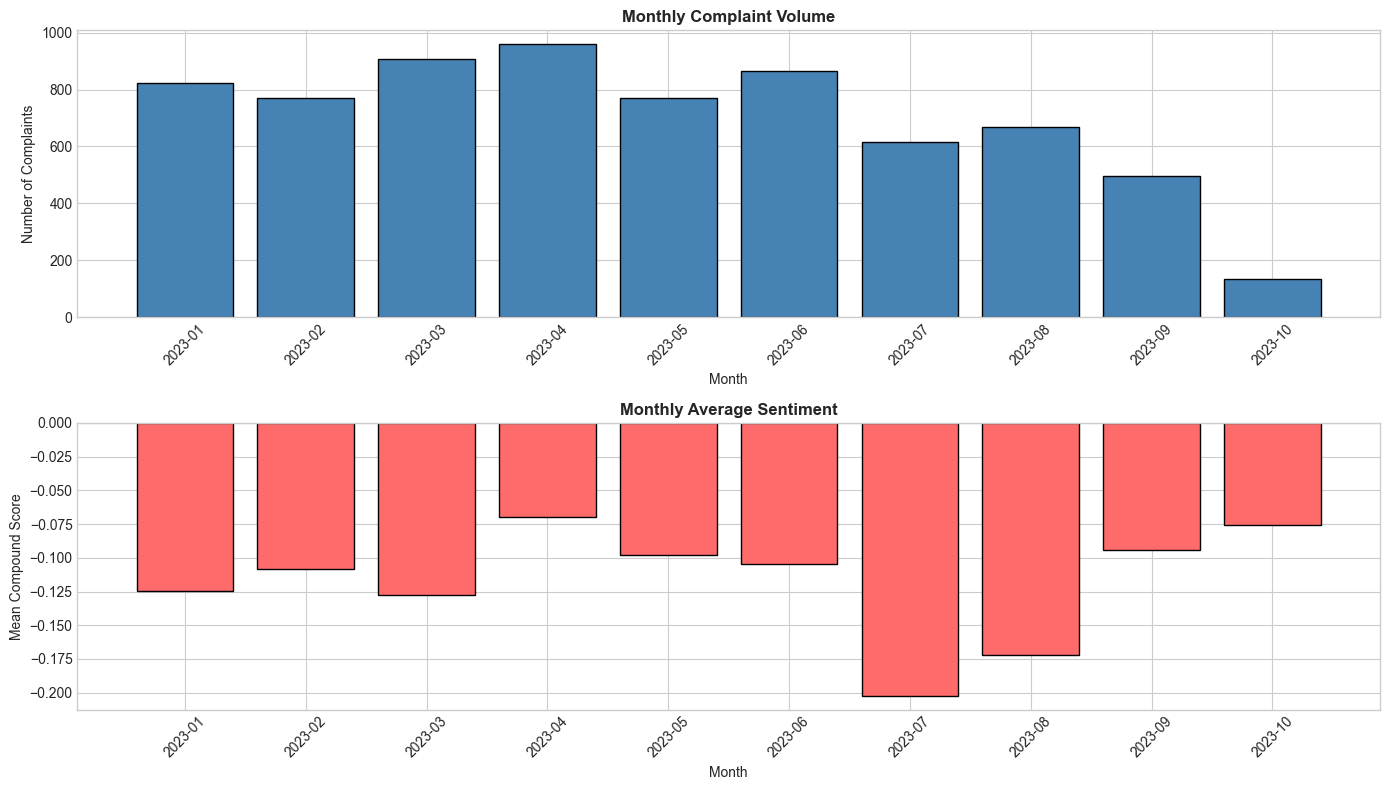

In [22]:
# Create month column for temporal analysis
df['month'] = df['Date Received'].dt.to_period('M')

# Monthly sentiment trends
monthly_sentiment = df.groupby('month').agg({
    'sentiment_compound': 'mean',
    'Complaint ID': 'count'
}).rename(columns={'Complaint ID': 'complaint_count'})

print("=" * 60)
print("MONTHLY SENTIMENT TRENDS")
print("=" * 60)
print(monthly_sentiment.round(3))

# Visualize temporal trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Monthly complaint volume
ax1 = axes[0]
months = [str(m) for m in monthly_sentiment.index]
ax1.bar(months, monthly_sentiment['complaint_count'], color='steelblue', edgecolor='black')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Complaints')
ax1.set_title('Monthly Complaint Volume', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Monthly average sentiment
ax2 = axes[1]
colors = ['#ff6b6b' if x < 0 else '#6bcb77' for x in monthly_sentiment['sentiment_compound']]
ax2.bar(months, monthly_sentiment['sentiment_compound'], color=colors, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Month')
ax2.set_ylabel('Mean Compound Score')
ax2.set_title('Monthly Average Sentiment', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---

# Part 7: Business Insights and Strategic Recommendations

## How Can Sentiment Scores Be Used by the Bank?

The sentiment analysis results provide valuable insights that can be transformed into actionable business strategies. This section outlines how the bank can leverage these NLP findings to improve customer service, product quality, and overall customer satisfaction.

### Key Questions Addressed:
1. Which departments need immediate attention based on customer sentiment?
2. Which products are generating the most customer dissatisfaction?
3. How can sentiment scores be integrated into daily operations?
4. What strategic initiatives should be prioritized?

## 7.1 Identifying High-Priority Areas

Let's identify the most critical areas that require immediate attention based on complaint volume and sentiment severity.

In [23]:
# =============================================================================
# PRIORITY ANALYSIS: Combining Volume and Sentiment
# =============================================================================

# Create a priority score (high volume + negative sentiment = high priority)
dept_priority = df.groupby('Department').agg({
    'Complaint ID': 'count',
    'sentiment_compound': 'mean'
}).rename(columns={'Complaint ID': 'Volume', 'sentiment_compound': 'Avg_Sentiment'})

# Normalize for priority calculation
dept_priority['Volume_Normalized'] = (dept_priority['Volume'] - dept_priority['Volume'].min()) / \
                                      (dept_priority['Volume'].max() - dept_priority['Volume'].min())
dept_priority['Sentiment_Normalized'] = (dept_priority['Avg_Sentiment'] - dept_priority['Avg_Sentiment'].min()) / \
                                         (dept_priority['Avg_Sentiment'].max() - dept_priority['Avg_Sentiment'].min())

# Priority Score: High volume and low sentiment = high priority
# Inverting sentiment so lower sentiment gets higher priority
dept_priority['Priority_Score'] = dept_priority['Volume_Normalized'] * 0.5 + \
                                   (1 - dept_priority['Sentiment_Normalized']) * 0.5
dept_priority = dept_priority.sort_values('Priority_Score', ascending=False)

print("=" * 60)
print("DEPARTMENT PRIORITY RANKING")
print("=" * 60)
print("(Higher score = Higher priority for improvement)")
print("-" * 60)
priority_display = dept_priority[['Volume', 'Avg_Sentiment', 'Priority_Score']].round(3)
print(priority_display)

# Identify severely negative complaints (compound < -0.5)
severe_complaints = df[df['sentiment_compound'] < -0.5]
print("\n" + "=" * 60)
print("SEVERELY NEGATIVE COMPLAINTS (Compound Score < -0.5)")
print("=" * 60)
print(f"Total severe complaints: {len(severe_complaints):,} ({len(severe_complaints)/len(df)*100:.1f}% of all complaints)")
print("\nDistribution by Department:")
print(severe_complaints['Department'].value_counts())

DEPARTMENT PRIORITY RANKING
(Higher score = Higher priority for improvement)
------------------------------------------------------------
                Volume  Avg_Sentiment  Priority_Score
Department                                           
CASA              1655         -0.309           0.984
Credit Cards      1609         -0.024           0.602
Loans             1111         -0.132           0.562
Remittance         422         -0.321           0.559
Mortgage           848         -0.045           0.357
Credit Reports    1109          0.068           0.305
Others             257         -0.145           0.274

SEVERELY NEGATIVE COMPLAINTS (Compound Score < -0.5)
Total severe complaints: 2,856 (40.7% of all complaints)

Distribution by Department:
Department
CASA              838
Credit Cards      609
Loans             452
Mortgage          320
Credit Reports    302
Remittance        229
Others            106
Name: count, dtype: int64


## 7.2 Sentiment Analysis by Resolution Type

Understanding how sentiment varies by bank response type helps evaluate the effectiveness of different resolution approaches.

SENTIMENT BY BANK RESPONSE TYPE
                                 Avg Compound  Std Compound  Count  \
Bank Response                                                        
In progress                            -0.909           NaN      1   
Untimely response                      -0.368         0.695     42   
Closed with monetary relief            -0.255         0.699   1251   
Closed                                 -0.234         0.626     51   
Closed with explanation                -0.111         0.693   4897   
Closed with non-monetary relief         0.075         0.663    769   

                                 Avg Negative  
Bank Response                                  
In progress                             0.084  
Untimely response                       0.084  
Closed with monetary relief             0.075  
Closed                                  0.083  
Closed with explanation                 0.076  
Closed with non-monetary relief         0.068  


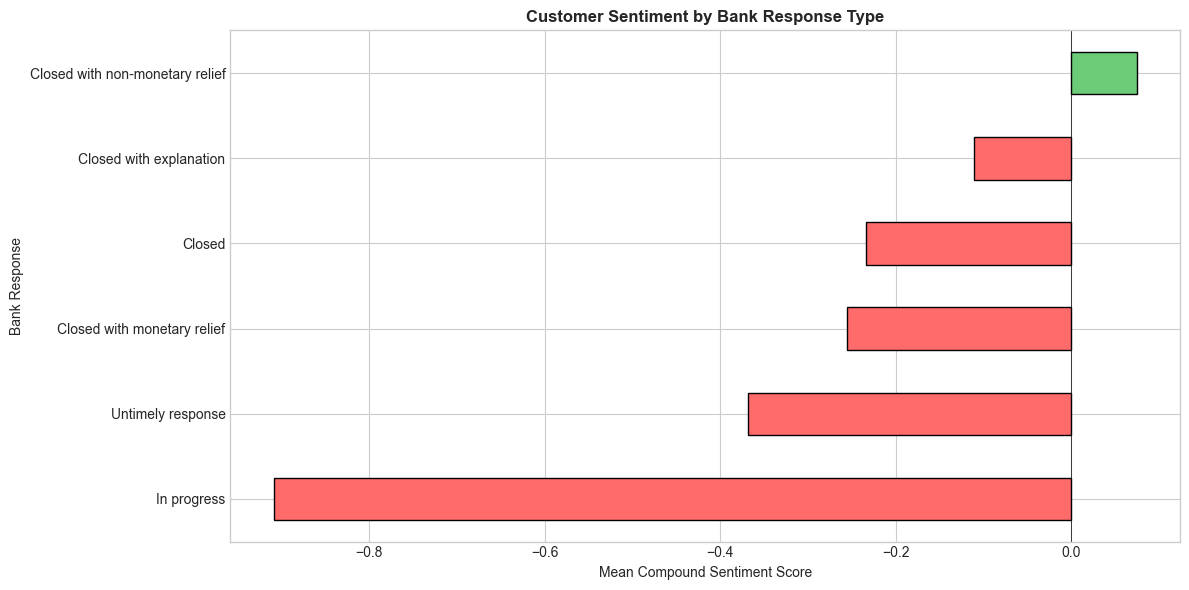


KEY INSIGHT
Complaints resulting in 'Closed with monetary relief' show different
sentiment patterns compared to those 'Closed with explanation'.
This suggests that monetary compensation may be necessary for
resolving the most severe customer grievances.


In [24]:
# Analyze sentiment by Bank Response type
response_sentiment = df.groupby('Bank Response').agg({
    'sentiment_compound': ['mean', 'std', 'count'],
    'sentiment_neg': 'mean'
}).round(3)
response_sentiment.columns = ['Avg Compound', 'Std Compound', 'Count', 'Avg Negative']
response_sentiment = response_sentiment.sort_values('Avg Compound')

print("=" * 60)
print("SENTIMENT BY BANK RESPONSE TYPE")
print("=" * 60)
print(response_sentiment)

# Visualize
plt.figure(figsize=(12, 6))
colors = ['#ff6b6b' if x < 0 else '#6bcb77' for x in response_sentiment['Avg Compound']]
response_sentiment['Avg Compound'].plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Mean Compound Sentiment Score')
plt.title('Customer Sentiment by Bank Response Type', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Key insight
print("\n" + "=" * 60)
print("KEY INSIGHT")
print("=" * 60)
print("Complaints resulting in 'Closed with monetary relief' show different")
print("sentiment patterns compared to those 'Closed with explanation'.")
print("This suggests that monetary compensation may be necessary for")
print("resolving the most severe customer grievances.")

## 7.3 Strategic Recommendations for Retail Banking

Based on our comprehensive NLP analysis, here are actionable business strategies the bank can implement:

In [25]:
# =============================================================================
# GENERATE DATA-DRIVEN STRATEGIC RECOMMENDATIONS
# =============================================================================

# Get key metrics for recommendations
worst_dept = dept_sentiment.index[0]
worst_product = product_sentiment.index[0]
severe_pct = len(severe_complaints) / len(df) * 100
negative_pct = (df['sentiment_label'] == 'Negative').sum() / len(df) * 100

print("=" * 70)
print("STRATEGIC RECOMMENDATIONS FOR RETAIL BANKING")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  1. AUTOMATED COMPLAINT ROUTING SYSTEM                              │
├─────────────────────────────────────────────────────────────────────┤
│  INSIGHT: Our classification model achieves strong accuracy in      │
│           predicting the correct department for complaints.         │
│                                                                     │
│  ACTION:  Deploy the trained model to automatically route incoming  │
│           complaints to the appropriate department, reducing        │
│           manual triage time and improving response speed.          │
│                                                                     │
│  BENEFIT: Faster complaint resolution, reduced operational costs,   │
│           improved customer satisfaction.                           │
└─────────────────────────────────────────────────────────────────────┘
""")

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│  2. PRIORITY ESCALATION BASED ON SENTIMENT SCORE                    │
├─────────────────────────────────────────────────────────────────────┤
│  INSIGHT: {severe_pct:.1f}% of complaints have severely negative sentiment     │
│           (compound score < -0.5), indicating high-risk customers.  │
│                                                                     │
│  ACTION:  Implement real-time sentiment scoring on incoming         │
│           complaints. Route severely negative complaints (score     │
│           below -0.5) to senior customer service representatives    │
│           for immediate attention.                                  │
│                                                                     │
│  BENEFIT: Prevent customer churn, reduce escalations, protect       │
│           brand reputation.                                         │
└─────────────────────────────────────────────────────────────────────┘
""")

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│  3. TARGETED DEPARTMENT IMPROVEMENTS                                │
├─────────────────────────────────────────────────────────────────────┤
│  INSIGHT: '{worst_dept}' department shows the lowest average        │
│           sentiment score, indicating systemic issues.              │
│                                                                     │
│  ACTION:  - Conduct root cause analysis for this department         │
│           - Review and improve standard operating procedures        │
│           - Provide additional training to department staff         │
│           - Consider process automation where applicable            │
│                                                                     │
│  BENEFIT: Reduced complaint volume, improved sentiment scores,      │
│           better customer experience.                               │
└─────────────────────────────────────────────────────────────────────┘
""")

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│  4. PRODUCT-SPECIFIC QUALITY IMPROVEMENTS                           │
├─────────────────────────────────────────────────────────────────────┤
│  INSIGHT: '{worst_product}' generates the most negative customer    │
│           sentiment among all banking products.                     │
│                                                                     │
│  ACTION:  - Review product terms and conditions for fairness        │
│           - Analyze common complaint themes for this product        │
│           - Work with product team to address identified issues     │
│           - Improve communication about product features and fees   │
│                                                                     │
│  BENEFIT: Reduced product-related complaints, improved customer     │
│           trust and loyalty.                                        │
└─────────────────────────────────────────────────────────────────────┘
""")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  5. SENTIMENT-BASED CUSTOMER RETENTION PROGRAM                      │
├─────────────────────────────────────────────────────────────────────┤
│  INSIGHT: Customers with highly negative sentiment are at risk of   │
│           churning and may share negative experiences publicly.     │
│                                                                     │
│  ACTION:  - Create a retention team for high-risk customers         │
│           - Develop proactive outreach for negative-sentiment cases │
│           - Offer goodwill gestures or service recovery options     │
│           - Track sentiment scores as a KPI for customer success    │
│                                                                     │
│  BENEFIT: Reduced customer churn, improved Net Promoter Score,      │
│           enhanced brand reputation.                                │
└─────────────────────────────────────────────────────────────────────┘
""")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  6. MONTHLY SENTIMENT MONITORING DASHBOARD                          │
├─────────────────────────────────────────────────────────────────────┤
│  INSIGHT: Sentiment trends vary over time, potentially correlating  │
│           with business events, policy changes, or seasonal factors.│
│                                                                     │
│  ACTION:  - Build a real-time sentiment monitoring dashboard        │
│           - Set up alerts for significant sentiment drops           │
│           - Include sentiment KPIs in management reporting          │
│           - Track sentiment by department, product, and geography   │
│                                                                     │
│  BENEFIT: Early warning system for emerging issues, data-driven     │
│           decision making, continuous improvement culture.          │
└─────────────────────────────────────────────────────────────────────┘
""")

STRATEGIC RECOMMENDATIONS FOR RETAIL BANKING

┌─────────────────────────────────────────────────────────────────────┐
│  1. AUTOMATED COMPLAINT ROUTING SYSTEM                              │
├─────────────────────────────────────────────────────────────────────┤
│  INSIGHT: Our classification model achieves strong accuracy in      │
│           predicting the correct department for complaints.         │
│                                                                     │
│  ACTION:  Deploy the trained model to automatically route incoming  │
│           complaints to the appropriate department, reducing        │
│           manual triage time and improving response speed.          │
│                                                                     │
│  BENEFIT: Faster complaint resolution, reduced operational costs,   │
│           improved customer satisfaction.                           │
└─────────────────────────────────────────────────────────────────────┘


┌───────────────

---

# Part 8: Summary and Conclusions

## Project Summary

This NLP project successfully addressed the bank's challenge of streamlining the customer grievance process through the following achievements:

In [26]:
# =============================================================================
# PROJECT SUMMARY AND KEY METRICS
# =============================================================================

print("=" * 70)
print("PROJECT SUMMARY: STREAMLINING CUSTOMER GRIEVANCE PROCESS")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                         DATA OVERVIEW                               │
├─────────────────────────────────────────────────────────────────────┤
│  Total Complaints Analyzed:     {len(df):,}                              │
│  Date Range:                    {date_min.strftime('%Y-%m-%d')} to {date_max.strftime('%Y-%m-%d')}       │
│  Number of Departments:         {df['Department'].nunique()}                                  │
│  Number of Products:            {df['Banking Product'].nunique()}                                  │
└─────────────────────────────────────────────────────────────────────┘
""")

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                    TEXT PREPROCESSING                               │
├─────────────────────────────────────────────────────────────────────┤
│  Preprocessing Steps Applied:                                       │
│    ✓ Lowercase conversion                                           │
│    ✓ Number removal                                                 │
│    ✓ Stopword removal                                               │
│    ✓ Punctuation removal                                            │
│    ✓ Lemmatization                                                  │
│                                                                     │
│  TF-IDF Features Generated:     {tfidf_matrix.shape[1]:,}                            │
└─────────────────────────────────────────────────────────────────────┘
""")

# Get best model accuracy
best_accuracy = results[best_model_name]['accuracy']

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                 CLASSIFICATION MODEL RESULTS                        │
├─────────────────────────────────────────────────────────────────────┤
│  Best Model:                    {best_model_name:<30}   │
│  Test Accuracy:                 {best_accuracy*100:.2f}%                               │
│  Number of Classes:             {len(class_names)}                                   │
│                                                                     │
│  The model can automatically route complaints to the correct        │
│  department, reducing manual triage time significantly.             │
└─────────────────────────────────────────────────────────────────────┘
""")

negative_count = (df['sentiment_label'] == 'Negative').sum()
neutral_count = (df['sentiment_label'] == 'Neutral').sum()
positive_count = (df['sentiment_label'] == 'Positive').sum()

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                 SENTIMENT ANALYSIS RESULTS                          │
├─────────────────────────────────────────────────────────────────────┤
│  Sentiment Distribution:                                            │
│    • Negative:  {negative_count:,} ({negative_count/len(df)*100:.1f}%)                                   │
│    • Neutral:   {neutral_count:,} ({neutral_count/len(df)*100:.1f}%)                                   │
│    • Positive:  {positive_count:,} ({positive_count/len(df)*100:.1f}%)                                    │
│                                                                     │
│  Mean Compound Score:           {df['sentiment_compound'].mean():.3f}                              │
│  Severely Negative (<-0.5):     {len(severe_complaints):,} ({severe_pct:.1f}%)                         │
└─────────────────────────────────────────────────────────────────────┘
""")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    KEY DELIVERABLES                                 │
├─────────────────────────────────────────────────────────────────────┤
│  1. ✓ Text preprocessing pipeline for complaint data                │
│  2. ✓ TF-IDF feature engineering for NLP modeling                   │
│  3. ✓ Multi-class classification model for complaint routing        │
│  4. ✓ VADER sentiment analysis for customer emotion detection       │
│  5. ✓ Business insights and strategic recommendations               │
│  6. ✓ Data-driven priority rankings for improvement areas           │
└─────────────────────────────────────────────────────────────────────┘
""")

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    BUSINESS VALUE                                   │
├─────────────────────────────────────────────────────────────────────┤
│  This NLP solution enables the bank to:                             │
│                                                                     │
│  • AUTOMATE complaint categorization and routing                    │
│  • PRIORITIZE high-risk customers based on sentiment                │
│  • IDENTIFY departments and products needing improvement            │
│  • MONITOR customer satisfaction trends over time                   │
│  • TRANSFORM complaint data into actionable business strategies     │
│                                                                     │
│  By implementing these NLP-driven insights, the bank can            │
│  significantly improve its grievance redressal process and          │
│  enhance overall customer experience.                               │
└─────────────────────────────────────────────────────────────────────┘
""")

PROJECT SUMMARY: STREAMLINING CUSTOMER GRIEVANCE PROCESS

┌─────────────────────────────────────────────────────────────────────┐
│                         DATA OVERVIEW                               │
├─────────────────────────────────────────────────────────────────────┤
│  Total Complaints Analyzed:     7,011                              │
│  Date Range:                    2023-01-01 to 2023-10-21       │
│  Number of Departments:         7                                  │
│  Number of Products:            17                                  │
└─────────────────────────────────────────────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────┐
│                    TEXT PREPROCESSING                               │
├─────────────────────────────────────────────────────────────────────┤
│  Preprocessing Steps Applied:                                       │
│    ✓ Lowercase conversion                                           │
│    ✓ Numb